# Learned Coarse-to-Fine Correction

A small neural network corrects the per-mode amplitudes of a coarser gyrokinetic solver to match a fine reference. The corrector sits **inside** the simulation loop: after each solver block it rescales $\delta f$ per $k_y$, and the corrected state feeds back into the next block. The full autoregressive chain is end-to-end differentiable.

Uses the validated iteration\_13 configuration. **Comparison**: fine solver vs coarse solver (5x cheaper) vs coarse + learned correction.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import logging

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_gpu_enable_command_buffer="
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

import sys
sys.path.append("..")

from gyaradax.bootstrap import init_jax
init_jax(device=5)

cuBLAS < 13.2 (120804 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


In [3]:
import numpy as np
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import equinox as eqx
from tqdm.auto import tqdm
from matplotlib.ticker import ScalarFormatter

from gyaradax import compute_geometry, GKParams, gk_init, gksolve
from gyaradax.solver import linear_precompute, default_state
from gyaradax.integrals import get_integrals
from gyaradax.plot_utils import JAX_COLORS, SPECIES_COLORS

jax.config.update("jax_enable_x64", True)

## Setup

Load the iteration\_13 configuration (validated nonlinear ITG case). Fine solver at dt=0.01, coarse at dt=0.05 (5x cheaper). Run to t=50.

In [12]:
from gyaradax.params import load_config, gkparams_from_config

cfg = load_config("../configs/iteration_13.yaml")

# compute geometry analytically from config
geometry = compute_geometry(
    q=float(cfg.geometry.q),
    shat=float(cfg.geometry.shat),
    eps=float(cfg.geometry.eps),
    ns=int(cfg.grid.ns),
    nkx=int(cfg.grid.nkx),
    nky=int(cfg.grid.nky),
    nvpar=int(cfg.grid.nvpar),
    nmu=int(cfg.grid.nmu),
    vpar_max=float(cfg.grid.vpar_max),
    nperiod=int(cfg.grid.nperiod),
    krhomax=float(cfg.grid.krhomax),
    ikxspace=int(cfg.grid.ikxspace),
)
ky = np.asarray(geometry["krho"])
kx = np.asarray(geometry["kxrh"])
NKY = len(ky)

# time parameters
T_FINAL = 3.0
FINE_DT = float(cfg.solver.dt)  # 0.01
COARSE_DT = 0.02               # 5x coarser

# block structure
FINE_STEPS_PER_BLOCK = int(cfg.solver.naverage)  # 40
COARSE_STEPS_PER_BLOCK = int(FINE_STEPS_PER_BLOCK * FINE_DT / COARSE_DT)  # 8
BLOCK_TIME = FINE_STEPS_PER_BLOCK * FINE_DT  # 0.4
N_BLOCKS = int(T_FINAL / BLOCK_TIME)

# build params from config, override dt and naverage for coarse
params_fine = gkparams_from_config(cfg)
params_coarse = gkparams_from_config(cfg, dt=COARSE_DT, naverage=COARSE_STEPS_PER_BLOCK)

print(f"grid: {geometry['vpgr'].shape[0]}x{geometry['mugr'].shape[0]}x{geometry['ints'].shape[0]}x{len(kx)}x{NKY}")
print(f"fine:   {N_BLOCKS} blocks x {FINE_STEPS_PER_BLOCK} steps @ dt={FINE_DT}, navg={FINE_STEPS_PER_BLOCK}")
print(f"coarse: {N_BLOCKS} blocks x {COARSE_STEPS_PER_BLOCK} steps @ dt={COARSE_DT}, navg={COARSE_STEPS_PER_BLOCK}")
print(f"block time: {BLOCK_TIME}, total time: {N_BLOCKS * BLOCK_TIME:.0f}")
print(f"fine RK4 evals: {N_BLOCKS * FINE_STEPS_PER_BLOCK}, coarse: {N_BLOCKS * COARSE_STEPS_PER_BLOCK}")

grid: 32x8x16x85x32
fine:   7 blocks x 40 steps @ dt=0.01, navg=40
coarse: 7 blocks x 20 steps @ dt=0.02, navg=20
block time: 0.4, total time: 3
fine RK4 evals: 280, coarse: 140


## Fine reference run

Run the fine solver (dt=0.01) for the full duration, collecting flux traces and $\phi$ snapshots at each block.

In [ ]:
from gyaradax.utils import load_gkw_k_dump, read_gkw_dump_time, K_files
from gyaradax.solver import GKState, mode_amplitude
from gyaradax.simulate import _compute_phi_for_init

data_dir = cfg.run.data_dir

# load initial condition from K01 (like run.py does)
k_files = K_files(data_dir)
k_path = os.path.join(data_dir, k_files[0])
res = tuple(len(geometry[k]) for k in ("intvp", "intmu", "ints", "kxrh", "krho"))
df_init = load_gkw_k_dump(k_path, res, n_species=1)

dat_path = k_path + ".dat"
t_start = read_gkw_dump_time(dat_path) if os.path.exists(dat_path) else 0.0
nky = len(ky)

phi0 = _compute_phi_for_init(df_init, geometry, params_fine)
amp0 = mode_amplitude(phi0, geometry, params_fine.norm_eps)
state_init = GKState(
    time=jnp.array(t_start, dtype=jnp.float64),
    step=jnp.array(0, dtype=jnp.int32),
    accumulated_norm_factor=jnp.ones(nky, dtype=jnp.float64),
    window_start_amp=amp0,
    last_growth_rate=jnp.zeros(nky, dtype=jnp.float64),
)

print(f"loaded K-file: {k_files[0]}, t_start={t_start:.2f}")
print(f"df shape: {df_init.shape}, |df|_max: {float(jnp.max(jnp.abs(df_init))):.4e}")

# run fine solver
pre_fine = linear_precompute(geometry, params_fine)
df_fine = jnp.array(df_init)
state_fine = state_init

fine_fluxes = []
fine_times = []
fine_phis = []

print("running fine solver...")
for b in tqdm(range(N_BLOCKS), desc="fine"):
    df_fine, (phi, fluxes), state_fine = gksolve(
        df_fine, geometry, params_fine, state_fine,
        n_steps=FINE_STEPS_PER_BLOCK, pre=pre_fine,
    )
    fine_fluxes.append([float(f) for f in fluxes])
    fine_times.append(float(state_fine.time))
    fine_phis.append(np.asarray(phi))

fine_fluxes = np.array(fine_fluxes)
fine_times = np.array(fine_times)
print(f"done. final time: {fine_times[-1]:.1f}")

loaded K-file: K01, t_start=1.20
df shape: (32, 8, 16, 85, 32), |df|_max: 8.2824e-03
running fine solver...


fine:   0%|          | 0/7 [00:00<?, ?it/s]

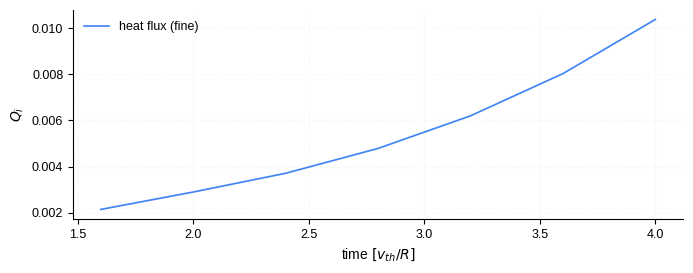

In [ ]:
# plot fine flux trace to verify turbulence develops
fig, ax = plt.subplots(figsize=(7.0, 2.8))
ax.plot(fine_times, fine_fluxes[:, 1], color=JAX_COLORS["blue"], label="heat flux (fine)")
ax.set_xlabel(r"time $[v_{th}/R]$")
ax.set_ylabel(r"$Q_i$")
ax.legend(frameon=False)
ax.grid(True)
fig.tight_layout()
plt.show()

## Coarse baseline

Run the uncorrected coarse solver (dt=0.05) to establish the baseline error.

In [ ]:
# coarse solver from the same K-file IC
pre_coarse = linear_precompute(geometry, params_coarse)
df_coarse = jnp.array(df_init)
state_coarse = GKState(
    time=jnp.array(t_start, dtype=jnp.float64),
    step=jnp.array(0, dtype=jnp.int32),
    accumulated_norm_factor=jnp.ones(nky, dtype=jnp.float64),
    window_start_amp=amp0,
    last_growth_rate=jnp.zeros(nky, dtype=jnp.float64),
)

coarse_fluxes = []
coarse_times = []
coarse_phis = []

print("running coarse solver...")
for b in tqdm(range(N_BLOCKS), desc="coarse"):
    df_coarse, (phi, fluxes), state_coarse = gksolve(
        df_coarse, geometry, params_coarse, state_coarse,
        n_steps=COARSE_STEPS_PER_BLOCK, pre=pre_coarse,
    )
    coarse_fluxes.append([float(f) for f in fluxes])
    coarse_times.append(float(state_coarse.time))
    coarse_phis.append(np.asarray(phi))

coarse_fluxes = np.array(coarse_fluxes)
coarse_times = np.array(coarse_times)
print(f"done. final time: {coarse_times[-1]:.1f}")

running coarse solver...


coarse:   0%|          | 0/7 [00:00<?, ?it/s]

done. final time: 4.0


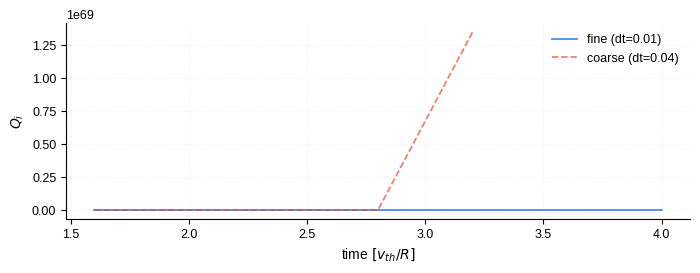

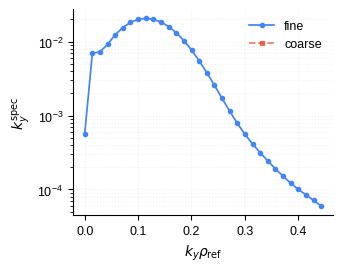

In [ ]:
# fine vs coarse flux comparison
fig, ax = plt.subplots(figsize=(7.0, 2.8))
ax.plot(fine_times, fine_fluxes[:, 1], color=JAX_COLORS["blue"], label=f"fine (dt={FINE_DT})")
ax.plot(coarse_times, coarse_fluxes[:, 1], color=JAX_COLORS["red"], alpha=0.7,
        ls="--", label=f"coarse (dt={COARSE_DT})")
ax.set_xlabel(r"time $[v_{th}/R]$")
ax.set_ylabel(r"$Q_i$")
ax.legend(frameon=False)
ax.grid(True)
fig.tight_layout()
plt.show()

# ky spectrum comparison at final time
def ky_spectrum(phi):
    return np.sum(np.abs(np.asarray(phi)) ** 2, axis=(0, 1))

fig, ax = plt.subplots(figsize=(3.5, 2.8))
ax.semilogy(ky, ky_spectrum(fine_phis[-1]), "o-", ms=3, color=JAX_COLORS["blue"], label="fine")
ax.semilogy(ky, ky_spectrum(coarse_phis[-1]), "s--", ms=3, color=JAX_COLORS["red"],
            alpha=0.7, label="coarse")
ax.set_xlabel(r"$k_y \rho_\mathrm{ref}$")
ax.set_ylabel(r"$k_y^{\mathrm{spec}}$")
ax.legend(frameon=False)
ax.grid(True, which="both")
fig.tight_layout()
plt.show()

## Correction network + corrected rollout

The MLP reads the $k_y$ spectral energy after each coarse block and outputs a per-mode multiplicative correction (residual around identity). The corrected $\delta f$ feeds back as IC for the next block.

In [9]:
class ModeCorrector(eqx.Module):
    """per-ky multiplicative correction, clamped to a safe range."""
    layers: list

    def __init__(self, n_ky, hidden=64, key=jax.random.PRNGKey(0)):
        k1, k2, k3 = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(n_ky, hidden, key=k1),
            eqx.nn.Linear(hidden, hidden, key=k2),
            eqx.nn.Linear(hidden, n_ky, key=k3),
        ]

    def __call__(self, ky_energy):
        x = ky_energy
        for layer in self.layers[:-1]:
            x = jax.nn.gelu(layer(x))
        raw = self.layers[-1](x)
        return 0.5 + 1.5 * jax.nn.sigmoid(raw)


network = ModeCorrector(NKY, hidden=64, key=jax.random.PRNGKey(42))

test_energy = jnp.ones(NKY)
init_corr = network(test_energy)
print(f"network params: {sum(x.size for x in jax.tree.leaves(network))}")
print(f"initial correction range: [{float(jnp.min(init_corr)):.3f}, {float(jnp.max(init_corr)):.3f}]")

network params: 8352
initial correction range: [1.182, 1.305]


In [10]:
def corrected_rollout(network, n_blocks):
    """coarse solver with learned per-block correction. returns flux trace + final phi."""
    df, state = gk_init(geometry, params_coarse)

    def block_fn(carry, _):
        df, state = carry
        df, (phi, fluxes), state = gksolve(
            df, geometry, params_coarse, state,
            n_steps=COARSE_STEPS_PER_BLOCK, pre=pre_coarse,
        )
        # per-ky spectral energy as network input
        ky_energy = jnp.sum(jnp.abs(phi) ** 2, axis=(0, 1))
        # learned correction
        correction = network(ky_energy)
        df = df * correction[None, None, None, None, :]
        return (df, state), (phi, fluxes)

    (final_df, final_state), (phi_hist, flux_hist) = jax.lax.scan(
        block_fn, (df, state), None, length=n_blocks
    )
    return final_df, phi_hist, flux_hist


# compile with a short run
print("compiling corrected rollout...")
_ = corrected_rollout(network, 2)
print("done")

compiling corrected rollout...
done


## Training

Truncated BPTT: backprop through short windows of coarse + correction blocks. Loss: MSE between corrected and fine $\phi$ at the window end.

In [11]:
TRAIN_BLOCKS = 1

# collect starting points from the coarse trajectory (starting from K-file IC)
fine_df_snapshots = []
df_snap = jnp.array(df_init)
state_snap = GKState(
    time=jnp.array(t_start, dtype=jnp.float64),
    step=jnp.array(0, dtype=jnp.int32),
    accumulated_norm_factor=jnp.ones(nky, dtype=jnp.float64),
    window_start_amp=amp0,
    last_growth_rate=jnp.zeros(nky, dtype=jnp.float64),
)
for b in range(N_BLOCKS):
    if b % (N_BLOCKS // 10) == 0:
        fine_df_snapshots.append((jnp.array(df_snap), state_snap))
    df_snap, _, state_snap = gksolve(
        df_snap, geometry, params_coarse, state_snap,
        n_steps=COARSE_STEPS_PER_BLOCK, pre=pre_coarse,
    )
print(f"collected {len(fine_df_snapshots)} starting points")


def corrected_window(network, df_init, state_init, n_blocks):
    def block_fn(carry, _):
        df, state = carry
        df, (phi, _), state = gksolve(
            df, geometry, params_coarse, state,
            n_steps=COARSE_STEPS_PER_BLOCK, pre=pre_coarse,
        )
        ky_energy = jnp.sum(jnp.abs(phi) ** 2, axis=(0, 1))
        correction = network(ky_energy)
        df = df * correction[None, None, None, None, :]
        return (df, state), phi

    (final_df, _), phi_hist = jax.lax.scan(
        block_fn, (df_init, state_init), None, length=n_blocks
    )
    return final_df, phi_hist


def fine_window(df_in, state_in, n_blocks):
    df, state = df_in, state_in
    for _ in range(n_blocks):
        df, (phi, _), state = gksolve(
            df, geometry, params_fine, state,
            n_steps=FINE_STEPS_PER_BLOCK, pre=pre_fine,
        )
    phi_final, _ = get_integrals(df, geometry, params=params_fine, pre=pre_fine,
                                  adiabatic_electrons=params_fine.adiabatic_electrons)
    return phi_final


@eqx.filter_jit
def loss_fn(network, df_in, state_in, phi_target):
    _, phi_hist = corrected_window(network, df_in, state_in, TRAIN_BLOCKS)
    phi_final = phi_hist[-1]
    return jnp.mean(jnp.abs(phi_final - phi_target) ** 2)


@eqx.filter_jit
def train_step(network, opt_state, df_in, state_in, phi_target):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(network, df_in, state_in, phi_target)
    updates, opt_state = optimizer.update(grads, opt_state, network)
    network = eqx.apply_updates(network, updates)
    return network, opt_state, loss


N_EPOCHS = 30
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(1e-4),
)
opt_state = optimizer.init(eqx.filter(network, eqx.is_array))
train_losses = []

# precompute fine targets
print("precomputing fine targets...")
train_data = []
for df_s, state_s in tqdm(fine_df_snapshots):
    phi_tgt = fine_window(df_s, state_s, TRAIN_BLOCKS)
    train_data.append((df_s, state_s, jnp.array(phi_tgt)))

# sanity check
df0, s0, pt0 = train_data[0]
l0 = loss_fn(network, df0, s0, pt0)
print(f"initial loss: {float(l0):.4e}")
print(f"phi_target finite: {bool(jnp.all(jnp.isfinite(pt0)))}")
print(f"phi_target range: [{float(jnp.min(jnp.abs(pt0))):.2e}, {float(jnp.max(jnp.abs(pt0))):.2e}]")

ZeroDivisionError: integer modulo by zero

In [ ]:
print(f"training on {len(train_data)} windows × {TRAIN_BLOCKS} blocks...")
pbar = tqdm(range(N_EPOCHS), desc="training")
for epoch in pbar:
    epoch_loss = 0.0
    for df_init, state_init, phi_tgt in train_data:
        network, opt_state, loss = train_step(network, opt_state, df_init, state_init, phi_tgt)
        epoch_loss += float(loss)
    epoch_loss /= len(train_data)
    train_losses.append(epoch_loss)
    pbar.set_postfix(loss=f"{epoch_loss:.3e}")

training on 13 windows × 1 blocks...


training:   0%|          | 0/30 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Evaluation

Three-way comparison: fine / coarse / coarse + correction. Show flux traces, $k_y$ spectra, and potential structure.

In [ ]:
# full corrected rollout (no grad needed, just inference)
def full_corrected_rollout(network):
    """run corrected coarse solver for all blocks, collecting fluxes."""
    df, state = gk_init(geometry, params_coarse)
    corr_fluxes = []
    corr_phis = []
    for b in range(N_BLOCKS):
        df, (phi, fluxes), state = gksolve(
            df, geometry, params_coarse, state,
            n_steps=COARSE_STEPS_PER_BLOCK, pre=pre_coarse,
        )
        # apply correction
        ky_energy = jnp.sum(jnp.abs(phi) ** 2, axis=(0, 1))
        correction = network(ky_energy)
        df = df * correction[None, None, None, None, :]

        corr_fluxes.append([float(f) for f in fluxes])
        corr_phis.append(np.asarray(phi))

    return np.array(corr_fluxes), corr_phis


print("running full corrected rollout...")
corr_fluxes, corr_phis = full_corrected_rollout(network)
corr_times = coarse_times
print("done")

In [ ]:
# --- flux trace comparison ---
fig, ax = plt.subplots(figsize=(7.0, 2.8))
ax.plot(fine_times, fine_fluxes[:, 1], color=JAX_COLORS["blue"],
        label=f"fine (dt={FINE_DT})")
ax.plot(coarse_times, coarse_fluxes[:, 1], color=JAX_COLORS["red"], ls="--",
        alpha=0.6, label=f"coarse (dt={COARSE_DT})")
ax.plot(corr_times, corr_fluxes[:, 1], color=JAX_COLORS["cyan"],
        label="coarse + correction")
ax.set_xlabel(r"time $[v_{th}/R]$")
ax.set_ylabel(r"$Q_i$")
ax.legend(frameon=False)
ax.grid(True)
fig.tight_layout()
fig.savefig("figs/correction_fluxes.pdf")
plt.show()

In [ ]:
# --- ky spectrum at final time ---
phi_fine_final = fine_phis[-1]
phi_coarse_final = coarse_phis[-1]
phi_corr_final = corr_phis[-1]

fig, ax = plt.subplots(figsize=(3.5, 2.8))
ax.semilogy(ky, ky_spectrum(phi_fine_final), "kx", ms=5, label="fine", zorder=3)
ax.semilogy(ky, ky_spectrum(phi_coarse_final), "s--", ms=3, color=JAX_COLORS["red"],
            alpha=0.6, label="coarse")
ax.semilogy(ky, ky_spectrum(phi_corr_final), "^-", ms=3, color=JAX_COLORS["cyan"],
            label="corrected")
ax.set_xlabel(r"$k_y \rho_\mathrm{ref}$")
ax.set_ylabel(r"$k_y^{\mathrm{spec}}$")
ax.legend(frameon=False)
ax.grid(True, which="both")
fig.tight_layout()
fig.savefig("figs/correction_spectrum.pdf")
plt.show()

In [ ]:
# --- |phi(s, kx)| at dominant ky: fine vs coarse vs corrected ---
ky_e = np.sum(np.abs(phi_fine_final) ** 2, axis=(0, 1))
iy_dom = int(np.argmax(ky_e[1:])) + 1

slices = {
    "fine": phi_fine_final[:, :, iy_dom],
    "coarse": phi_coarse_final[:, :, iy_dom],
    "corrected": phi_corr_final[:, :, iy_dom],
}
vmax = np.max(np.abs(phi_fine_final[:, :, iy_dom]))

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.8), sharey=True)
for ax, (label, phi_slice) in zip(axes, slices.items()):
    im = ax.matshow(np.abs(phi_slice), cmap="inferno", vmin=0, vmax=vmax, aspect="auto")
    ax.set_xlabel(r"$k_x$")
    ax.set_title(label, pad=12)
    ax.xaxis.set_ticks_position("bottom")
axes[0].set_ylabel(r"$s$")
fig.colorbar(im, ax=axes, shrink=0.85, label=r"$|\phi|$", location="right")
fig.suptitle(f"$k_y = {ky[iy_dom]:.3f}$", y=1.05)
fig.tight_layout()
fig.savefig("figs/correction_phi_skx.pdf")
plt.show()

In [ ]:
# --- training loss ---
fig, ax = plt.subplots(figsize=(3.5, 2.8))
ax.semilogy(train_losses, color=JAX_COLORS["purple"])
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.grid(True, which="both")
fig.tight_layout()
fig.savefig("figs/correction_loss.pdf")
plt.show()

# MSE summary
mse_coarse = float(jnp.mean(jnp.abs(jnp.array(phi_coarse_final) - jnp.array(phi_fine_final)) ** 2))
mse_corr = float(jnp.mean(jnp.abs(jnp.array(phi_corr_final) - jnp.array(phi_fine_final)) ** 2))
print(f"MSE coarse:    {mse_coarse:.4e}")
print(f"MSE corrected: {mse_corr:.4e}")
print(f"improvement:   {mse_coarse / max(mse_corr, 1e-30):.1f}x")